## 20251017 Now try to see offset relation for each galaxy and also the combined case

Total galaxies found: 14
Excluded galaxies: {'NGC4383'}
Included galaxies (13): ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']

Color assignments (preserving position for excluded galaxies):

Processing IC3392 (1/13)...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_36551/455807781.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(galaxies))


  Pearson: r = 0.035, p = 2.331e-05, N_unique = 2354

Processing NGC4064 (2/13)...
  Pearson: r = 0.520, p = 0.000e+00, N_unique = 2869

Processing NGC4192 (3/13)...
  Pearson: r = -0.037, p = 5.429e-46, N_unique = 6908

Processing NGC4293 (4/13)...
  Pearson: r = -0.039, p = 3.070e-03, N_unique = 442

Processing NGC4298 (5/13)...
  Pearson: r = -0.037, p = 5.429e-46, N_unique = 6908

Processing NGC4293 (4/13)...
  Pearson: r = -0.039, p = 3.070e-03, N_unique = 442

Processing NGC4298 (5/13)...
  Pearson: r = 0.270, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = 0.093, p = 7.687e-83, N_unique = 1760

Processing NGC4396 (7/13)...
  Pearson: r = 0.270, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = 0.093, p = 7.687e-83, N_unique = 1760

Processing NGC4396 (7/13)...
  Pearson: r = -0.285, p = 0.000e+00, N_unique = 1743

Processing NGC4419 (8/13)...
  Pearson: r = 0.581, p = 0.000e+00, N_unique = 1297

Processing NGC4457 (9/13)...
 

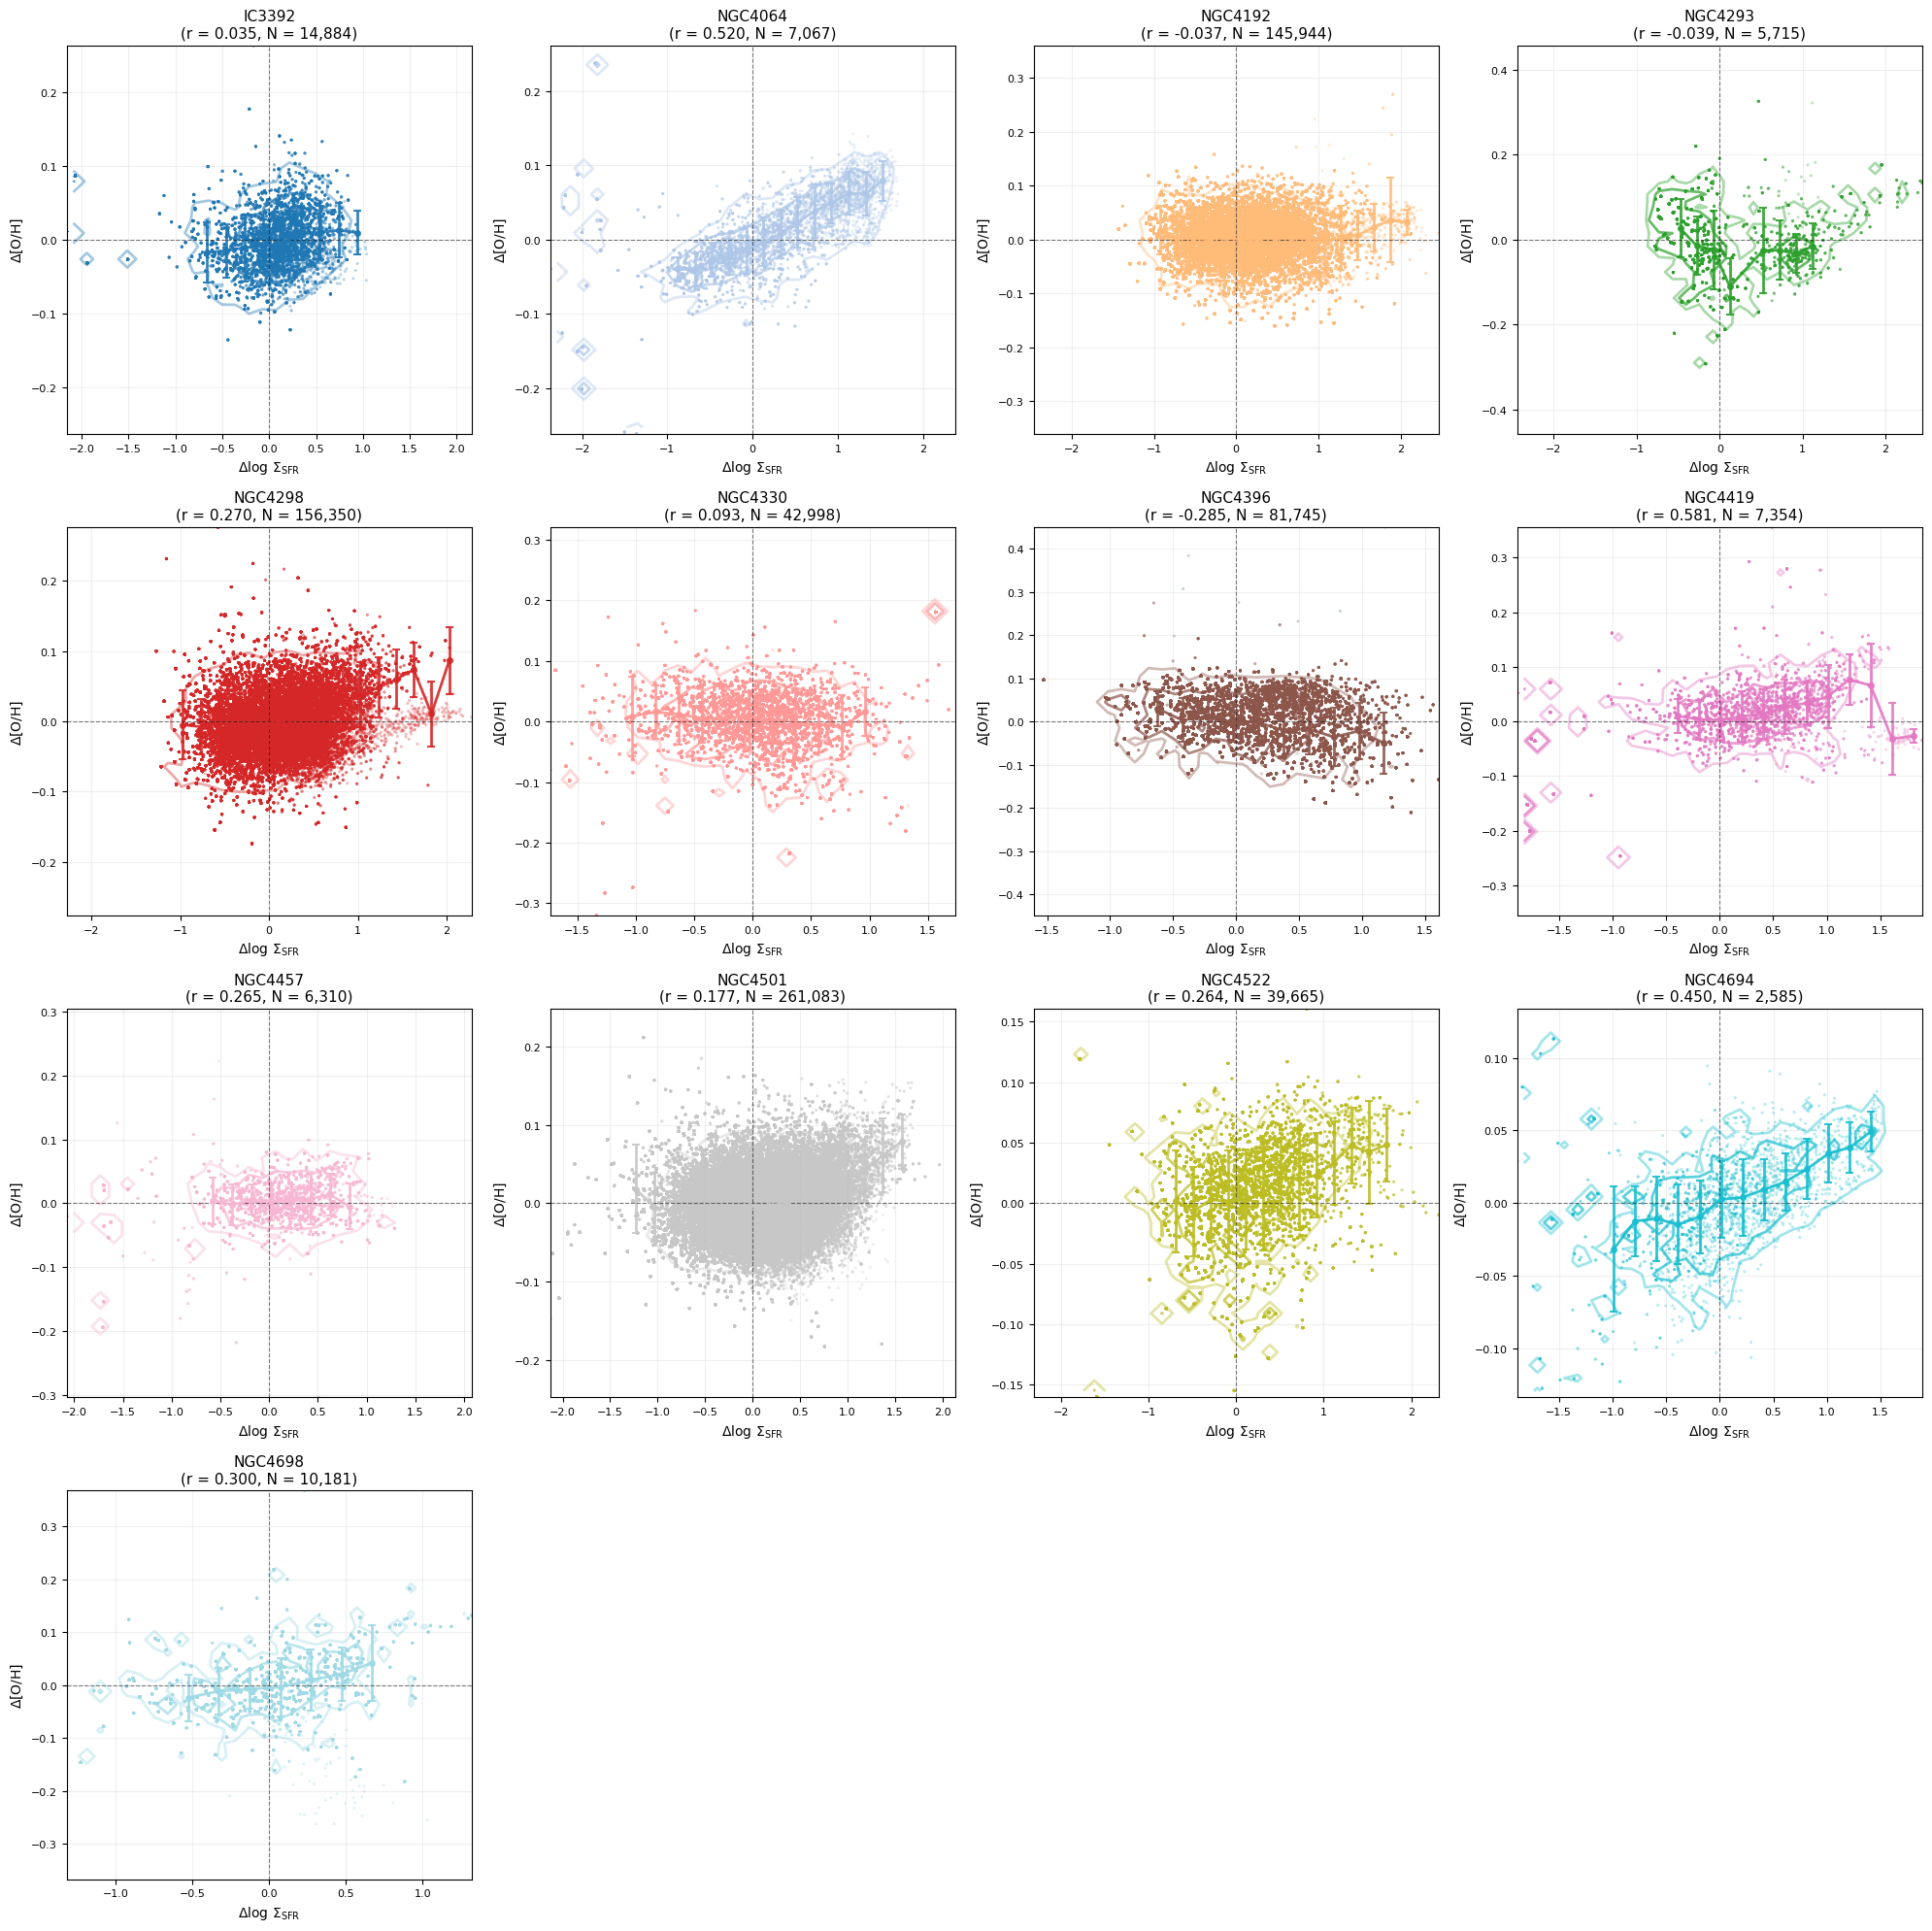


All plots complete!


In [1]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣSFR for all galaxies (4x4 subplot layout)
# Excluding NGC4383
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Total galaxies found: {len(galaxies)}")
print(f"Excluded galaxies: {excluded_galaxies}")
print(f"Included galaxies ({len(included_galaxies)}): {included_galaxies}")

# Create color map - preserve color position for all galaxies including excluded ones
import matplotlib.cm as cm
cmap = cm.get_cmap('tab20', len(galaxies))
galaxy_colors = {gal: cmap(i) for i, gal in enumerate(galaxies)}
print(f"\nColor assignments (preserving position for excluded galaxies):")

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Create 4x4 subplot layout
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, gal in enumerate(included_galaxies):
    if idx >= 16:  # Safety check for 4x4 grid
        break
    
    ax = axes[idx]
    
    # Get color for this galaxy
    gal_color = galaxy_colors[gal]
    
    try:
        print(f"\nProcessing {gal} ({idx+1}/{len(included_galaxies)})...")
        
        sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_all = valid_sfr & valid_oh

        # Calculate mean values for offset calculation
        sfr_mean = np.nanmean(sigSFR[valid_sfr])
        oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
        
        # Create offset maps (difference from mean)
        sfr_offset = sigSFR - sfr_mean
        oh_offset = oh_o3n2_map - oh_mean

        # Extract valid data points
        delta_sfr = sfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]

        # Calculate Pearson correlation only if >= 20 unique data points
        n_unique = len(np.unique(np.column_stack([delta_sfr, delta_oh]), axis=0))
        pearson_r = None
        if n_unique >= 20:
            pearson_r, pearson_p = pearsonr(delta_sfr, delta_oh)
            print(f"  Pearson: r = {pearson_r:.3f}, p = {pearson_p:.3e}, N_unique = {n_unique}")
        else:
            print(f"  Insufficient unique data (N_unique = {n_unique})")

        # Calculate symmetric axis limits
        max_abs_sfr = np.nanmax(np.abs(delta_sfr))
        max_abs_oh = np.nanmax(np.abs(delta_oh))

        # Scatter plot with galaxy-specific color
        ax.scatter(delta_sfr, delta_oh, c=[gal_color], s=5, alpha=0.3, edgecolors='none', rasterized=True)

        # Create 2D histogram for contours
        H, xedges, yedges = np.histogram2d(delta_sfr, delta_oh, bins=30,
                                           range=[[-max_abs_sfr, max_abs_sfr],
                                                  [-max_abs_oh, max_abs_oh]])
        H = H.T
        
        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]
        
        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.4, 0.7]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.7, 0.4]
        else:
            levels_to_plot = [level_68]
            colors_to_plot = [gal_color]
            alphas = [0.7]
        
        if len(levels_to_plot) > 0:
            for level, color, alpha in zip(levels_to_plot, colors_to_plot, alphas):
                ax.contour(X, Y, H, levels=[level], colors=[color],
                          linewidths=[2], alpha=alpha)
        
        # Calculate median trend
        bin_centers, medians, stds, counts = calculate_binned_stats(
            delta_sfr, delta_oh, bin_width=0.2, min_pixels=20)
        
        if len(bin_centers) > 0:
            ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                       color=gal_color, markersize=4, linewidth=2, capsize=3, 
                       capthick=1.5, alpha=0.9)
        
        # Set symmetric limits
        ax.set_xlim(-max_abs_sfr, max_abs_sfr)
        ax.set_ylim(-max_abs_oh, max_abs_oh)

        # Add grid and center lines
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.2)

        # Labels
        ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=10)
        ax.set_ylabel(r'$\Delta$[O/H]', fontsize=10)
        
        # Title with galaxy name and correlation
        if pearson_r is not None:
            ax.set_title(f'{gal}\n(r = {pearson_r:.3f}, N = {len(delta_sfr):,})', fontsize=11)
        else:
            ax.set_title(f'{gal}\n(N = {len(delta_sfr):,})', fontsize=11)
        
        ax.tick_params(labelsize=8)
        
    except Exception as e:
        print(f"  Error processing {gal}: {e}")
        ax.text(0.5, 0.5, f'{gal}\nError', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='red')
        ax.set_xticks([])
        ax.set_yticks([])

# Hide any unused subplots
for idx in range(len(included_galaxies), 16):
    axes[idx].axis('off')

plt.tight_layout()
# plt.savefig('All_Galaxies_Delta_OH_vs_Delta_SigmaSFR_4x4.png', dpi=300, bbox_inches='tight')
# plt.savefig('All_Galaxies_Delta_OH_vs_Delta_SigmaSFR_4x4.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("All plots complete!")
print("="*60)

Creating combined plot for 13 galaxies...
Included galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']
Loading IC3392...
  IC3392: 14,884 pixels
Loading NGC4064...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_36551/430079435.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(galaxies))


  NGC4064: 7,067 pixels
Loading NGC4192...
  NGC4192: 145,944 pixels
Loading NGC4293...
  NGC4293: 5,715 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4330: 42,998 pixels
Loading NGC4396...
  NGC4192: 145,944 pixels
Loading NGC4293...
  NGC4293: 5,715 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4330: 42,998 pixels
Loading NGC4396...
  NGC4396: 81,745 pixels
Loading NGC4419...
  NGC4396: 81,745 pixels
Loading NGC4419...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4457: 6,310 pixels
Loading NGC4501...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4457: 6,310 pixels
Loading NGC4501...
  NGC4501: 261,083 pixels
Loading NGC4522...
  NGC4501: 261,083 pixels
Loading NGC4522...
  NGC4522: 39,665 pixels
Loading NGC4694...
  NGC4694: 2,585 pixels
Loading NGC4698...
  NGC4698: 10,181 pixels

Total combined pixels: 781,881  NGC4522: 39,665 pixels
Loading NGC4694...
  NGC4694: 2,585 pixels
Loading NGC4698...
  NGC4698: 10,181 pixel

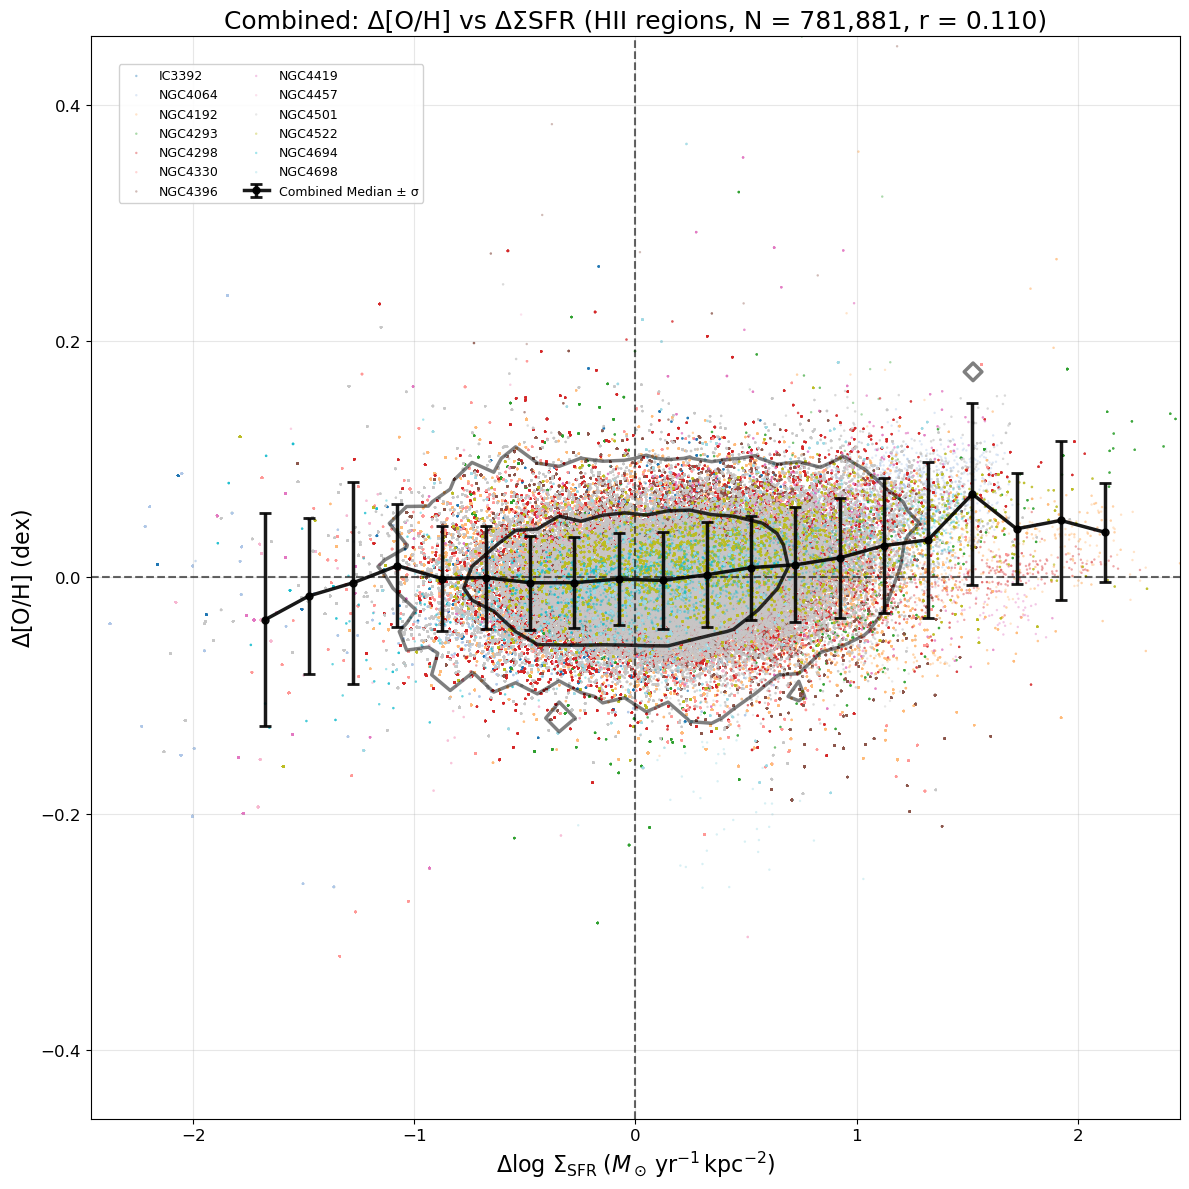


Combined plot complete!


In [2]:
# ------------------------------------------------------------------
# Combined plot: All galaxies in a single panel
# Each galaxy colored differently, with black combined contours and median trend
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.cm as cm

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

# Create color map - preserve color position for all galaxies including excluded ones
cmap = cm.get_cmap('tab20', len(galaxies))
galaxy_colors = {gal: cmap(i) for i, gal in enumerate(galaxies)}

print(f"Creating combined plot for {len(included_galaxies)} galaxies...")
print(f"Included galaxies: {included_galaxies}")

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Collect data from all galaxies
# ------------------------------------------------------------------
all_delta_sfr = []
all_delta_oh = []
all_colors = []
galaxy_data = {}

for gal in included_galaxies:
    try:
        print(f"Loading {gal}...")
        sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_all = valid_sfr & valid_oh

        # Calculate mean values for offset calculation
        sfr_mean = np.nanmean(sigSFR[valid_sfr])
        oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
        
        # Create offset maps (difference from mean)
        sfr_offset = sigSFR - sfr_mean
        oh_offset = oh_o3n2_map - oh_mean

        # Extract valid data points
        delta_sfr = sfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]
        
        # Store for this galaxy
        galaxy_data[gal] = {
            'delta_sfr': delta_sfr,
            'delta_oh': delta_oh,
            'color': galaxy_colors[gal]
        }
        
        # Add to combined arrays
        all_delta_sfr.extend(delta_sfr)
        all_delta_oh.extend(delta_oh)
        all_colors.extend([galaxy_colors[gal]] * len(delta_sfr))
        
        print(f"  {gal}: {len(delta_sfr):,} pixels")
        
    except Exception as e:
        print(f"  Error loading {gal}: {e}")

# Convert to numpy arrays
all_delta_sfr = np.array(all_delta_sfr)
all_delta_oh = np.array(all_delta_oh)
all_colors = np.array(all_colors)

print(f"\nTotal combined pixels: {len(all_delta_sfr):,}")

# ------------------------------------------------------------------
# Create combined plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

# Calculate symmetric axis limits for all data
max_abs_sfr = np.nanmax(np.abs(all_delta_sfr))
max_abs_oh = np.nanmax(np.abs(all_delta_oh))

# Plot scatter points for each galaxy with its color
for gal in included_galaxies:
    if gal in galaxy_data:
        data = galaxy_data[gal]
        ax.scatter(data['delta_sfr'], data['delta_oh'], 
                  c=[data['color']], s=3, alpha=0.4, edgecolors='none', 
                  rasterized=True, label=gal)

# Create 2D histogram for COMBINED contours (in black)
H, xedges, yedges = np.histogram2d(all_delta_sfr, all_delta_oh, bins=50,
                                   range=[[-max_abs_sfr, max_abs_sfr],
                                          [-max_abs_oh, max_abs_oh]])
H = H.T

# Calculate cumulative distribution for contour levels
H_sorted = np.sort(H.flatten())[::-1]
H_cumsum = np.cumsum(H_sorted)
H_cumsum = H_cumsum / H_cumsum[-1]

# Find levels for 68% and 95%
level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]

# Plot COMBINED contours in black
X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
if level_95 < level_68:
    levels_to_plot = [level_95, level_68]
    alphas = [0.5, 0.8]
elif level_95 > level_68:
    levels_to_plot = [level_68, level_95]
    alphas = [0.8, 0.5]
else:
    levels_to_plot = [level_68]
    alphas = [0.8]

if len(levels_to_plot) > 0:
    for level, alpha in zip(levels_to_plot, alphas):
        ax.contour(X, Y, H, levels=[level], colors=['black'],
                  linewidths=[2.5], alpha=alpha)

# Calculate COMBINED median trend (in black)
bin_centers, medians, stds, counts = calculate_binned_stats(
    all_delta_sfr, all_delta_oh, bin_width=0.2, min_pixels=20)

if len(bin_centers) > 0:
    ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
               color='black', markersize=5, linewidth=2.5, capsize=4, 
               capthick=2, alpha=0.9, label='Combined Median ± σ', zorder=10)

# Calculate Pearson correlation for combined data
n_unique = len(np.unique(np.column_stack([all_delta_sfr, all_delta_oh]), axis=0))
if n_unique >= 20:
    pearson_r, pearson_p = pearsonr(all_delta_sfr, all_delta_oh)
    print(f"\nCombined Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.3e}")
else:
    pearson_r = None
    print(f"\nInsufficient unique data for correlation (N_unique = {n_unique})")

# Set symmetric limits
ax.set_xlim(-max_abs_sfr, max_abs_sfr)
ax.set_ylim(-max_abs_oh, max_abs_oh)

# Add grid and center lines
ax.axhline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
ax.grid(True, alpha=0.3)

# Labels
ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=16)
ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=16)

# Title
if pearson_r is not None:
    title = f'Combined: Δ[O/H] vs ΔΣSFR (HII regions, N = {len(all_delta_sfr):,}, r = {pearson_r:.3f})'
else:
    title = f'Combined: Δ[O/H] vs ΔΣSFR (HII regions, N = {len(all_delta_sfr):,})'
ax.set_title(title, fontsize=18)

# Legend
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9, 
         bbox_to_anchor=(0.02, 0.98))

ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig('Combined_All_Galaxies_Delta_OH_vs_Delta_SigmaSFR.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_All_Galaxies_Delta_OH_vs_Delta_SigmaSFR.pdf', bbox_inches='tight')
plt.show()

print("\nCombined plot complete!")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 12 equal-width SFR bins for rMZR

Σ_SFR range:
  Min: -4.567
  Max: 0.019
  Range: 4.586

Bin width: 0.382

12 equal-width SFR bins:
  Bin 1: -4.57–-4.18
  Bin 2: -4.18–-3.80
  Bin 3: -3.80–-3.42
  Bin 4: -3.42–-3.0

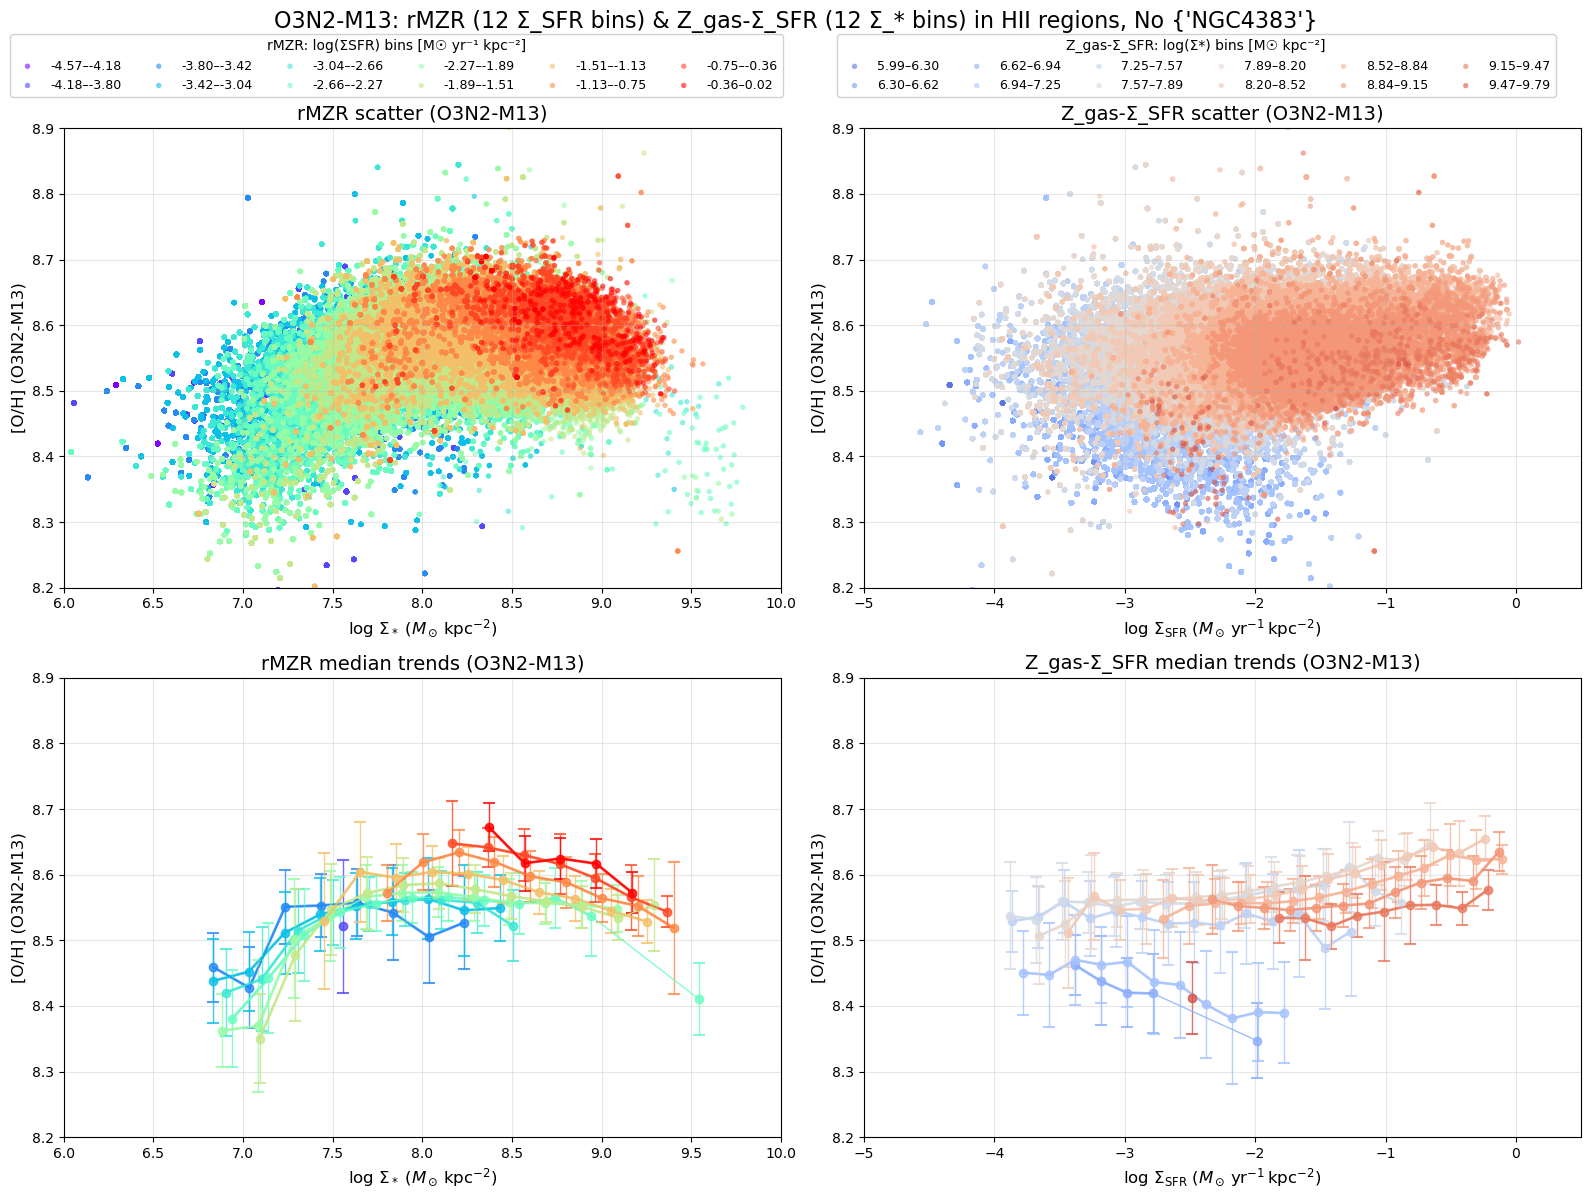


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (12 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [3]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_SFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width SFR bins for rMZR")
print("="*80)

# Get SFR range
sfr_min = np.min(all_logSigmaSFR_HII)
sfr_max = np.max(all_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range:")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = sfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_SFR bins) & Z_gas-Σ_SFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR

Σ_* Statistics:
  Min: 5.986
  Max: 9.787
  Range: 3.801
  Bin width: 0.317 dex

12 Σ_* bins (equal width):
  Bin 1: 5.99–6.30
  Bin 2: 6.30–6.62
  Bin 3: 6.62–6.94
  Bi

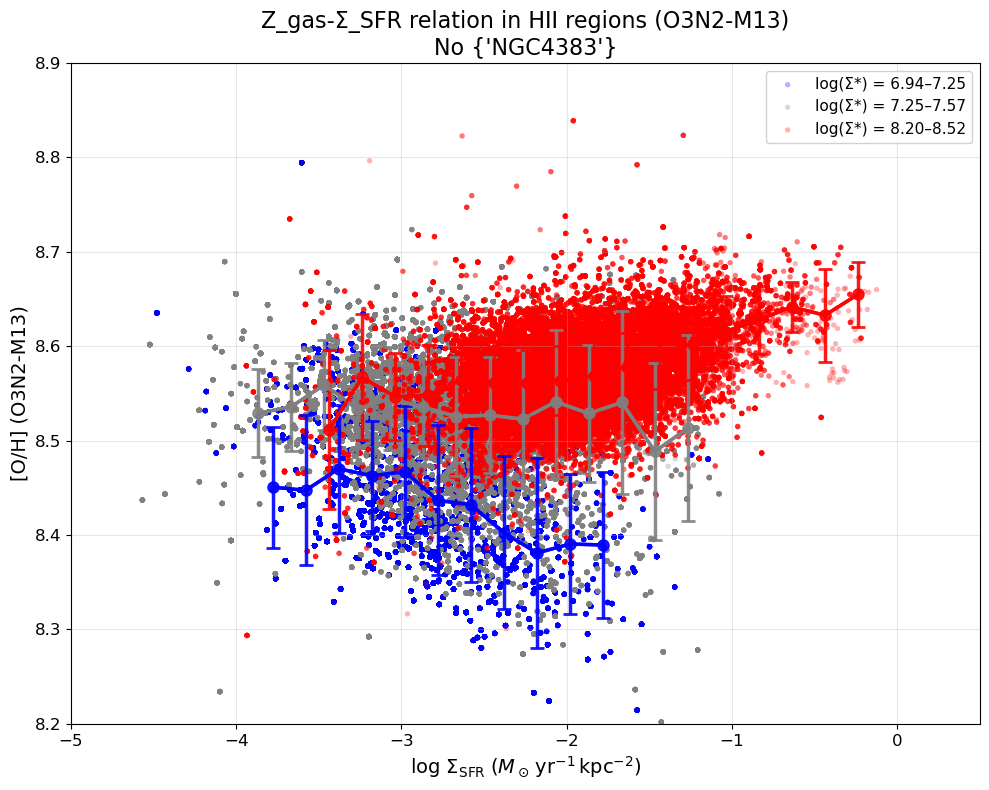


COMPLETED: Z_gas-Σ_SFR analysis with 3 selected bins
Successfully created plot showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383


In [4]:
# ------------------------------------------------------------------
# Z_gas-Σ_SFR relation - HII regions only (O3N2-M13)
# Show only 3 specific Σ_* bins: most decreasing, most flat, most increasing
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# ==============================================================================
# STEP 3: Calculate trends for all 12 bins and identify 3 specific bins
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Analyzing trends in all 12 Σ_* bins")
print("="*80)

oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

# Store trend information for each bin
bin_trends = []

for i in range(n_bins_sigmaM):
    # Select data in this Σ_* bin
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Calculate binned statistics
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        # If we have valid bins, calculate the trend
        # Require at least 10 median data points
        if len(medians_HII) >= 10:
            first_median = medians_HII[0]
            last_median = medians_HII[-1]
            trend = last_median - first_median  # Positive = increasing, Negative = decreasing
            
            bin_trends.append({
                'bin_index': i,
                'bin_label': bin_labels_sigmaM[i],
                'trend': trend,
                'first_median': first_median,
                'last_median': last_median,
                'sfr_centers': sfr_centers_HII,
                'medians': medians_HII,
                'stds': stds_HII,
                'valid_bin_indices': valid_bin_indices_HII,
                'x_data': x_bin_HII,
                'y_data': y_bin_HII
            })
            
            print(f"  Bin {i+1} ({bin_labels_sigmaM[i]}): trend = {trend:.4f} (first={first_median:.3f}, last={last_median:.3f}), N_median_pts={len(medians_HII)}")
        elif len(medians_HII) > 0:
            print(f"  Bin {i+1} ({bin_labels_sigmaM[i]}): insufficient median points (N={len(medians_HII)} < 10)")

# Identify the 3 specific bins
if len(bin_trends) > 0:
    # Sort by trend value
    sorted_by_trend = sorted(bin_trends, key=lambda x: x['trend'])
    
    most_decreasing = sorted_by_trend[0]  # Most negative trend
    most_flat = min(bin_trends, key=lambda x: abs(x['trend']))  # Closest to zero
    most_increasing = sorted_by_trend[-1]  # Most positive trend
    
    print("\n" + "="*80)
    print("Selected 3 bins:")
    print("="*80)
    print(f"  Most decreasing: Bin {most_decreasing['bin_index']+1}, Σ_* = {most_decreasing['bin_label']}, trend = {most_decreasing['trend']:.4f}")
    print(f"  Most flat: Bin {most_flat['bin_index']+1}, Σ_* = {most_flat['bin_label']}, trend = {most_flat['trend']:.4f}")
    print(f"  Most increasing: Bin {most_increasing['bin_index']+1}, Σ_* = {most_increasing['bin_label']}, trend = {most_increasing['trend']:.4f}")
    
    # ==============================================================================
    # STEP 4: Create single panel plot with 3 selected bins
    # ==============================================================================
    print("\n" + "="*80)
    print("STEP 4: Creating Z_gas-Σ_SFR plot with 3 selected bins")
    print("="*80)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Set uniform y-axis range
    common_ylim = (8.2, 8.9)
    
    # Define colors for the 3 bins
    color_decreasing = 'blue'
    color_flat = 'gray'
    color_increasing = 'red'
    
    selected_bins = [
        (most_decreasing, color_decreasing, 'Most Decreasing'),
        (most_flat, color_flat, 'Most Flat'),
        (most_increasing, color_increasing, 'Most Increasing')
    ]
    
    # Plot each selected bin
    for bin_data, color, description in selected_bins:
        bin_idx = bin_data['bin_index']
        bin_label = bin_data['bin_label']
        x_data = bin_data['x_data']
        y_data = bin_data['y_data']
        sfr_centers = bin_data['sfr_centers']
        medians = bin_data['medians']
        stds = bin_data['stds']
        valid_bin_indices = bin_data['valid_bin_indices']
        
        # Scatter plot
        ax.scatter(x_data, y_data, c=color, s=15, alpha=0.3, 
                  edgecolors='none', rasterized=True, label=f'log(Σ*) = {bin_label}')
        
        # Median trend with error bars
        ax.errorbar(sfr_centers, medians, yerr=stds, 
                   color=color, marker='o', markersize=8, 
                   linewidth=2.5, capsize=5, capthick=2, alpha=0.9)
        
        # Add lines between adjacent bins
        for j in range(len(valid_bin_indices) - 1):
            current_bin_idx = valid_bin_indices[j]
            next_bin_idx = valid_bin_indices[j + 1]
            if next_bin_idx - current_bin_idx == 1:
                ax.plot([sfr_centers[j], sfr_centers[j + 1]], 
                       [medians[j], medians[j + 1]], 
                       color=color, linewidth=2.5, alpha=0.9)
    
    # Format plot
    ax.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=14)
    ax.set_title(f'Z_gas-Σ_SFR relation in HII regions ({calib_name_HII})\nNo {excluded_galaxies}', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5.0, 0.5)
    ax.set_ylim(common_ylim)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.tick_params(labelsize=12)
    
    plt.tight_layout()
    # plt.savefig('Zgas_SigmaSFR_O3N2M13_3selected_bins.png', dpi=300, bbox_inches='tight')
    # plt.savefig('Zgas_SigmaSFR_O3N2M13_3selected_bins.pdf', bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("COMPLETED: Z_gas-Σ_SFR analysis with 3 selected bins")
    print("="*80)
    print(f"Successfully created plot showing HII regions from {len(included_galaxies)} galaxies")
    print(f"Galaxies included: {', '.join(included_galaxies)}")
    print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
else:
    print("\nNo valid bins found for analysis!")



Creating 3-panel subplot:
  Top: Most decreasing (Σ_* = 6.94–7.25)
  Middle: Most flat (Σ_* = 7.25–7.57)
  Bottom: Most increasing (Σ_* = 8.20–8.52)

Creating 3-panel subplot:
  Top: Most decreasing (Σ_* = 6.94–7.25)
  Middle: Most flat (Σ_* = 7.25–7.57)
  Bottom: Most increasing (Σ_* = 8.20–8.52)


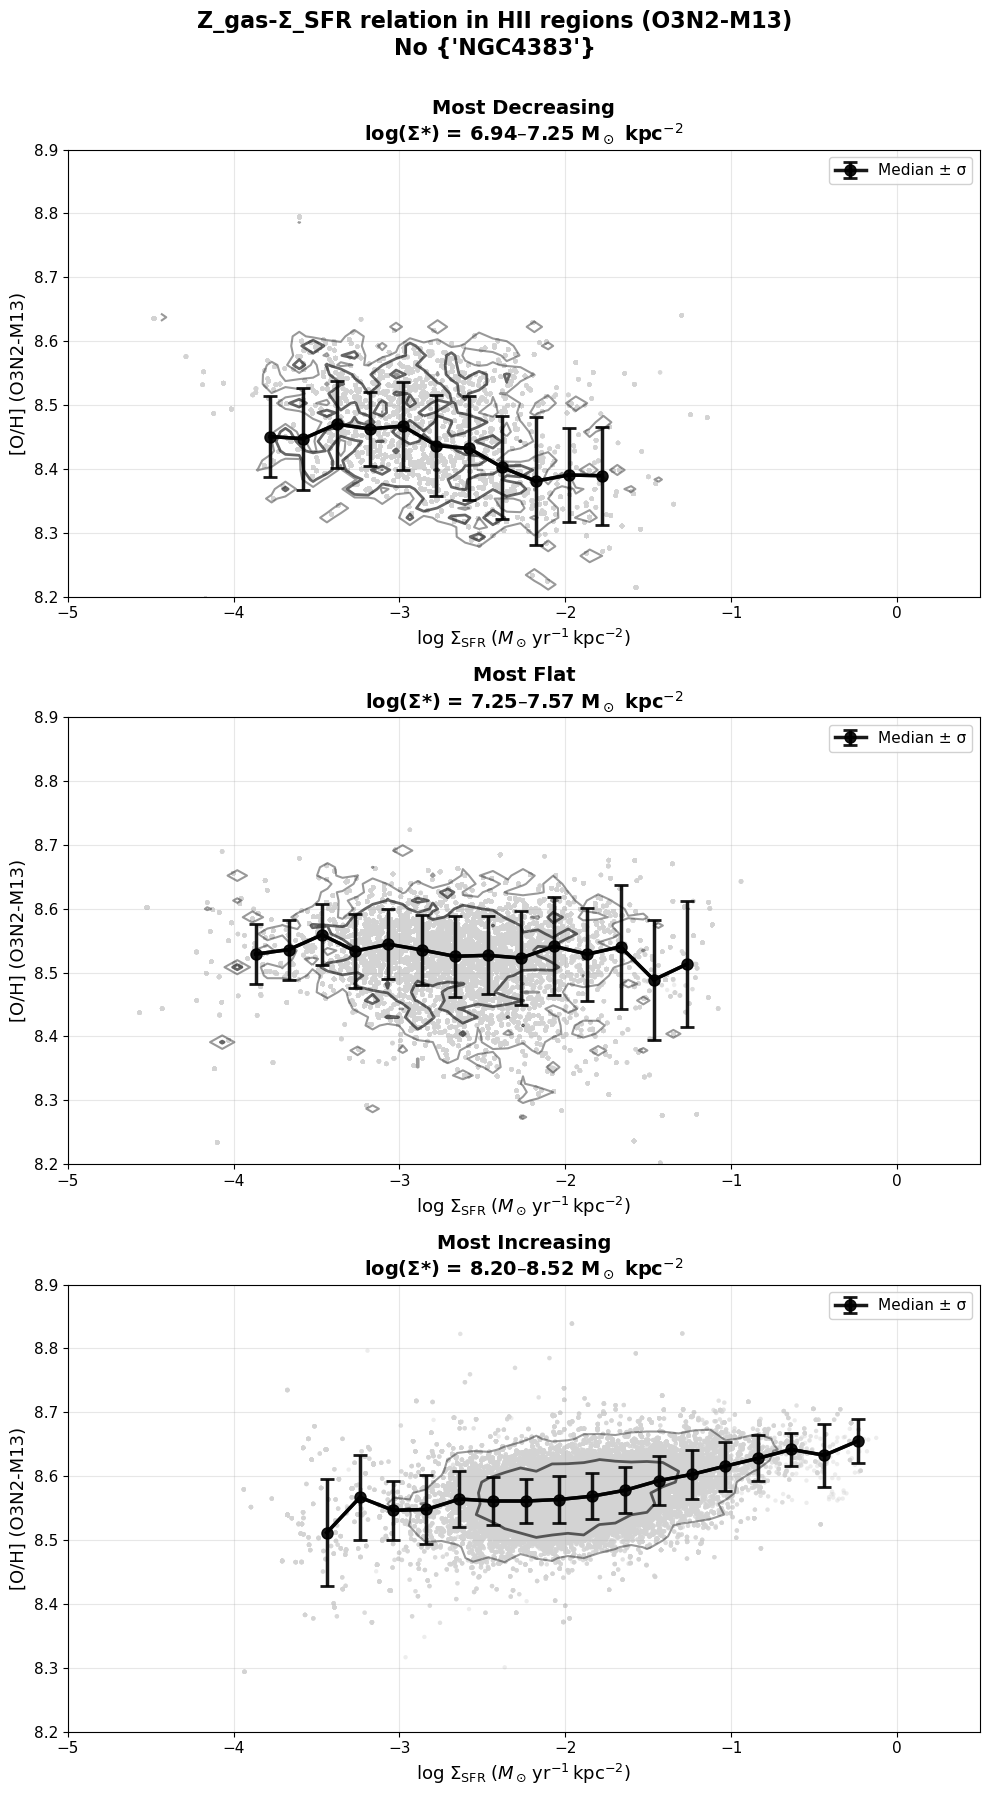


COMPLETED: 3-panel subplot showing most decreasing, flat, and increasing bins


In [5]:
# ------------------------------------------------------------------
# Z_gas-Σ_SFR relation - 3 separate subplots (3 rows x 1 column)
# Show most decreasing, most flat, and most increasing bins separately
# Using black for median trends and contours
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

excluded_galaxies = {'NGC4383'}
included_galaxies = []

# Collect data
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("Collecting data for 3-panel subplot...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

# Define 12 Σ_* bins
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
n_bins_sigmaM = 12
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

# Analyze all bins and identify 3 specific ones
bin_trends = []

for i in range(n_bins_sigmaM):
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(medians_HII) >= 10:
            first_median = medians_HII[0]
            last_median = medians_HII[-1]
            trend = last_median - first_median
            
            bin_trends.append({
                'bin_index': i,
                'bin_label': bin_labels_sigmaM[i],
                'trend': trend,
                'first_median': first_median,
                'last_median': last_median,
                'sfr_centers': sfr_centers_HII,
                'medians': medians_HII,
                'stds': stds_HII,
                'valid_bin_indices': valid_bin_indices_HII,
                'x_data': x_bin_HII,
                'y_data': y_bin_HII
            })

# Identify the 3 specific bins
if len(bin_trends) > 0:
    sorted_by_trend = sorted(bin_trends, key=lambda x: x['trend'])
    
    most_decreasing = sorted_by_trend[0]
    most_flat = min(bin_trends, key=lambda x: abs(x['trend']))
    most_increasing = sorted_by_trend[-1]
    
    print(f"\nCreating 3-panel subplot:")
    print(f"  Top: Most decreasing (Σ_* = {most_decreasing['bin_label']})")
    print(f"  Middle: Most flat (Σ_* = {most_flat['bin_label']})")
    print(f"  Bottom: Most increasing (Σ_* = {most_increasing['bin_label']})")
    
    # Create 3x1 subplot
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))
    
    common_ylim = (8.2, 8.9)
    
    selected_bins = [
        (most_decreasing, 'Most Decreasing', axes[0]),
        (most_flat, 'Most Flat', axes[1]),
        (most_increasing, 'Most Increasing', axes[2])
    ]
    
    # Plot each bin in separate subplot
    for bin_data, description, ax in selected_bins:
        bin_label = bin_data['bin_label']
        x_data = bin_data['x_data']
        y_data = bin_data['y_data']
        sfr_centers = bin_data['sfr_centers']
        medians = bin_data['medians']
        stds = bin_data['stds']
        valid_bin_indices = bin_data['valid_bin_indices']
        
        # Scatter plot in light gray
        ax.scatter(x_data, y_data, c='lightgray', s=10, alpha=0.4, 
                  edgecolors='none', rasterized=True)
        
        # Create 2D histogram for contours
        x_min, x_max = np.min(x_data), np.max(x_data)
        y_min, y_max = np.min(y_data), np.max(y_data)
        
        H, xedges, yedges = np.histogram2d(x_data, y_data, bins=40,
                                           range=[[x_min, x_max], [y_min, y_max]])
        H = H.T
        
        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]
        
        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours in black
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            alphas = [0.4, 0.6]
            linewidths = [1.5, 2.0]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            alphas = [0.6, 0.4]
            linewidths = [2.0, 1.5]
        else:
            levels_to_plot = [level_68]
            alphas = [0.6]
            linewidths = [2.0]
        
        if len(levels_to_plot) > 0:
            for level, alpha, lw in zip(levels_to_plot, alphas, linewidths):
                ax.contour(X, Y, H, levels=[level], colors=['black'],
                          linewidths=[lw], alpha=alpha)
        
        # Median trend with error bars in black
        ax.errorbar(sfr_centers, medians, yerr=stds, 
                   color='black', marker='o', markersize=8, 
                   linewidth=2.5, capsize=5, capthick=2, alpha=0.9,
                   label='Median ± σ', zorder=10)
        
        # Add lines between adjacent bins
        for j in range(len(valid_bin_indices) - 1):
            current_bin_idx = valid_bin_indices[j]
            next_bin_idx = valid_bin_indices[j + 1]
            if next_bin_idx - current_bin_idx == 1:
                ax.plot([sfr_centers[j], sfr_centers[j + 1]], 
                       [medians[j], medians[j + 1]], 
                       color='black', linewidth=2.5, alpha=0.9, zorder=10)
        
        # Format subplot
        ax.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=13)
        ax.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=13)
        ax.set_title(f'{description}\nlog(Σ*) = {bin_label} M$_\\odot$ kpc$^{{-2}}$', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5.0, 0.5)
        ax.set_ylim(common_ylim)
        ax.legend(loc='best', fontsize=11, framealpha=0.9)
        ax.tick_params(labelsize=11)
    
    # Add overall title
    fig.suptitle(f'Z_gas-Σ_SFR relation in HII regions ({calib_name_HII})\nNo {excluded_galaxies}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # plt.savefig('Zgas_SigmaSFR_O3N2M13_3bins_separate_panels.png', dpi=300, bbox_inches='tight')
    # plt.savefig('Zgas_SigmaSFR_O3N2M13_3bins_separate_panels.pdf', bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("COMPLETED: 3-panel subplot showing most decreasing, flat, and increasing bins")
    print("="*80)
else:
    print("\nNo valid bins found for analysis!")



Creating 3-panel subplot for offset relation:
  Top: Most decreasing (Σ_* = 6.94–7.25)
  Middle: Most flat (Σ_* = 7.25–7.57)
  Bottom: Most increasing (Σ_* = 8.20–8.52)

Creating 3-panel subplot for offset relation:
  Top: Most decreasing (Σ_* = 6.94–7.25)
  Middle: Most flat (Σ_* = 7.25–7.57)
  Bottom: Most increasing (Σ_* = 8.20–8.52)


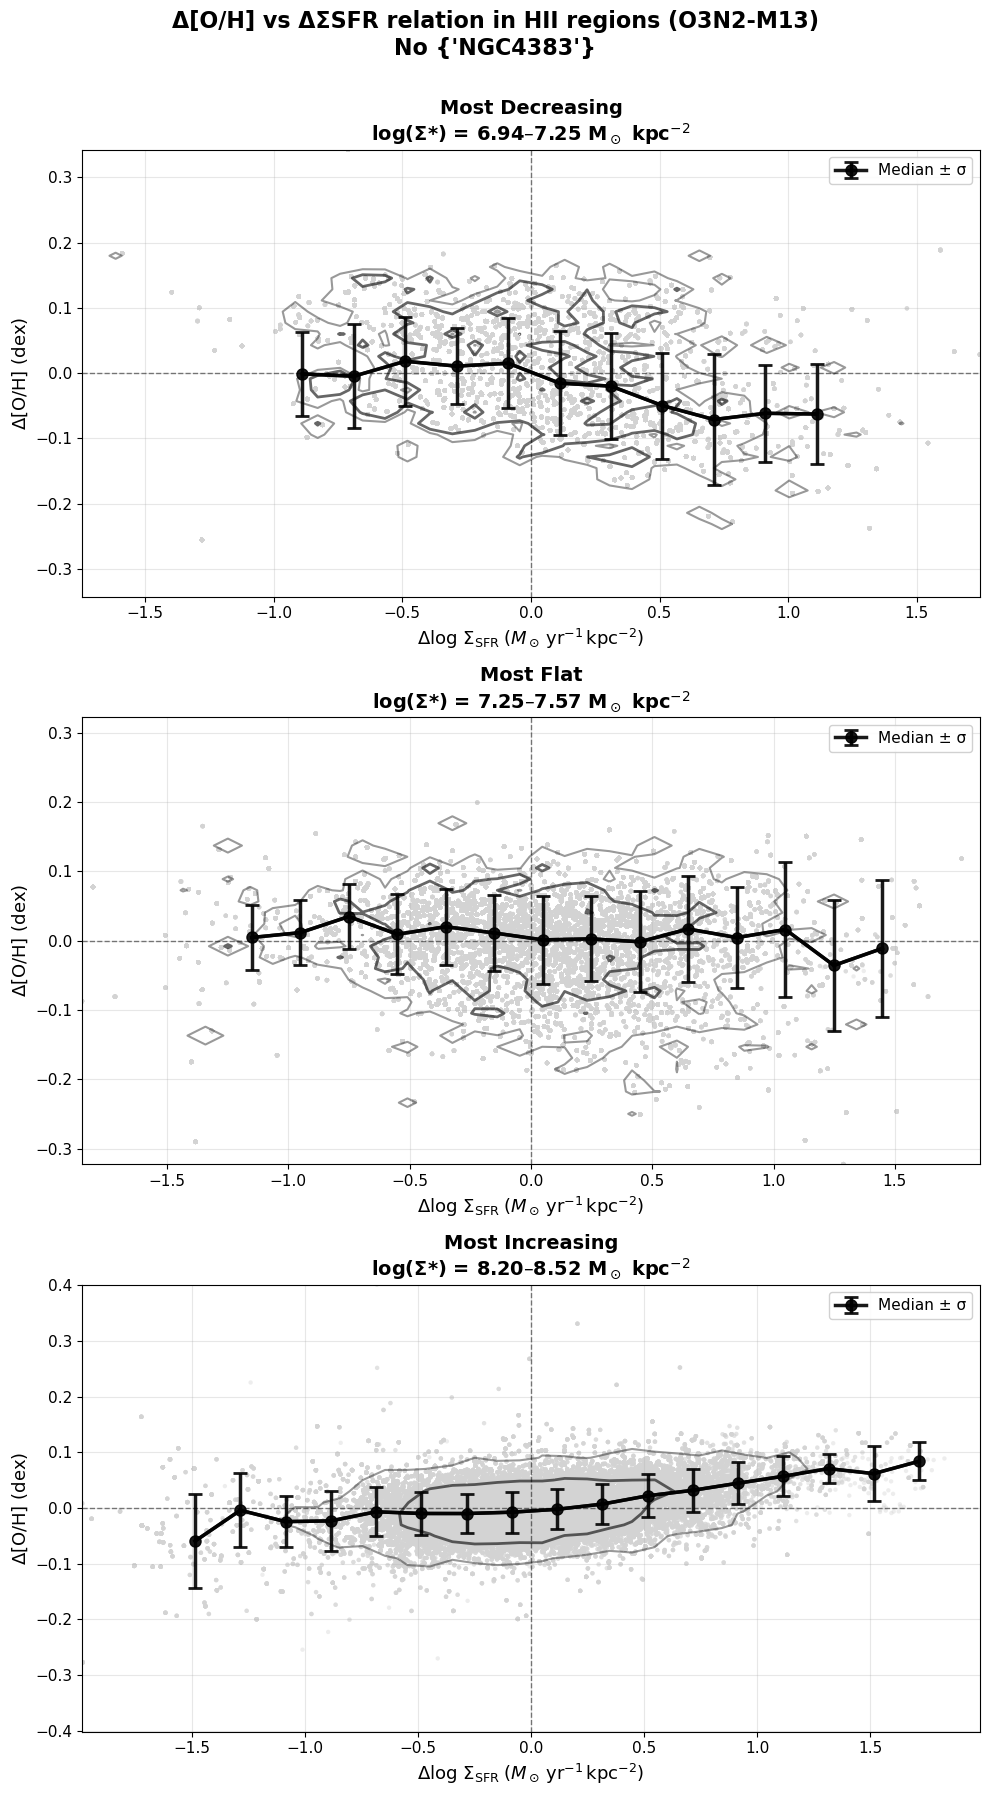


COMPLETED: 3-panel subplot showing Δ[O/H] vs ΔΣSFR offset relation


In [6]:
# ------------------------------------------------------------------
# Δ[O/H] vs ΔΣSFR relation - 3 separate subplots (3 rows x 1 column)
# Show most decreasing, most flat, and most increasing bins separately
# Using black for median trends and contours
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

excluded_galaxies = {'NGC4383'}
included_galaxies = []

# Collect data
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("Collecting data for Δ[O/H] vs ΔΣSFR 3-panel subplot...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

# Define 12 Σ_* bins
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
n_bins_sigmaM = 12
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

# Analyze all bins and identify 3 specific ones
# For each bin, calculate offset relative to the bin's mean
bin_trends = []

for i in range(n_bins_sigmaM):
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Calculate offsets for this bin
        sfr_mean = np.nanmean(x_bin_HII)
        oh_mean = np.nanmean(y_bin_HII)
        
        delta_sfr = x_bin_HII - sfr_mean
        delta_oh = y_bin_HII - oh_mean
        
        # Calculate binned statistics on offsets
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            delta_sfr, delta_oh, bin_width=0.2, min_pixels=20)
        
        if len(medians_HII) >= 10:
            first_median = medians_HII[0]
            last_median = medians_HII[-1]
            trend = last_median - first_median
            
            bin_trends.append({
                'bin_index': i,
                'bin_label': bin_labels_sigmaM[i],
                'trend': trend,
                'first_median': first_median,
                'last_median': last_median,
                'sfr_centers': sfr_centers_HII,
                'medians': medians_HII,
                'stds': stds_HII,
                'valid_bin_indices': valid_bin_indices_HII,
                'delta_sfr': delta_sfr,
                'delta_oh': delta_oh
            })

# Identify the 3 specific bins
if len(bin_trends) > 0:
    sorted_by_trend = sorted(bin_trends, key=lambda x: x['trend'])
    
    most_decreasing = sorted_by_trend[0]
    most_flat = min(bin_trends, key=lambda x: abs(x['trend']))
    most_increasing = sorted_by_trend[-1]
    
    print(f"\nCreating 3-panel subplot for offset relation:")
    print(f"  Top: Most decreasing (Σ_* = {most_decreasing['bin_label']})")
    print(f"  Middle: Most flat (Σ_* = {most_flat['bin_label']})")
    print(f"  Bottom: Most increasing (Σ_* = {most_increasing['bin_label']})")
    
    # Create 3x1 subplot
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))
    
    selected_bins = [
        (most_decreasing, 'Most Decreasing', axes[0]),
        (most_flat, 'Most Flat', axes[1]),
        (most_increasing, 'Most Increasing', axes[2])
    ]
    
    # Plot each bin in separate subplot
    for bin_data, description, ax in selected_bins:
        bin_label = bin_data['bin_label']
        delta_sfr = bin_data['delta_sfr']
        delta_oh = bin_data['delta_oh']
        sfr_centers = bin_data['sfr_centers']
        medians = bin_data['medians']
        stds = bin_data['stds']
        valid_bin_indices = bin_data['valid_bin_indices']
        
        # Calculate symmetric axis limits
        max_abs_sfr = np.nanmax(np.abs(delta_sfr))
        max_abs_oh = np.nanmax(np.abs(delta_oh))
        
        # Scatter plot in light gray
        ax.scatter(delta_sfr, delta_oh, c='lightgray', s=10, alpha=0.4, 
                  edgecolors='none', rasterized=True)
        
        # Create 2D histogram for contours
        H, xedges, yedges = np.histogram2d(delta_sfr, delta_oh, bins=40,
                                           range=[[-max_abs_sfr, max_abs_sfr],
                                                  [-max_abs_oh, max_abs_oh]])
        H = H.T
        
        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]
        
        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours in black
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            alphas = [0.4, 0.6]
            linewidths = [1.5, 2.0]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            alphas = [0.6, 0.4]
            linewidths = [2.0, 1.5]
        else:
            levels_to_plot = [level_68]
            alphas = [0.6]
            linewidths = [2.0]
        
        if len(levels_to_plot) > 0:
            for level, alpha, lw in zip(levels_to_plot, alphas, linewidths):
                ax.contour(X, Y, H, levels=[level], colors=['black'],
                          linewidths=[lw], alpha=alpha)
        
        # Median trend with error bars in black
        ax.errorbar(sfr_centers, medians, yerr=stds, 
                   color='black', marker='o', markersize=8, 
                   linewidth=2.5, capsize=5, capthick=2, alpha=0.9,
                   label='Median ± σ', zorder=10)
        
        # Add lines between adjacent bins
        for j in range(len(valid_bin_indices) - 1):
            current_bin_idx = valid_bin_indices[j]
            next_bin_idx = valid_bin_indices[j + 1]
            if next_bin_idx - current_bin_idx == 1:
                ax.plot([sfr_centers[j], sfr_centers[j + 1]], 
                       [medians[j], medians[j + 1]], 
                       color='black', linewidth=2.5, alpha=0.9, zorder=10)
        
        # Add center lines
        ax.axhline(0, color='k', linestyle='--', linewidth=1.0, alpha=0.5)
        ax.axvline(0, color='k', linestyle='--', linewidth=1.0, alpha=0.5)
        
        # Format subplot
        ax.set_xlabel(r'$\Delta\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=13)
        ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=13)
        ax.set_title(f'{description}\nlog(Σ*) = {bin_label} M$_\\odot$ kpc$^{{-2}}$', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-max_abs_sfr, max_abs_sfr)
        ax.set_ylim(-max_abs_oh, max_abs_oh)
        ax.legend(loc='best', fontsize=11, framealpha=0.9)
        ax.tick_params(labelsize=11)
    
    # Add overall title
    fig.suptitle(f'Δ[O/H] vs ΔΣSFR relation in HII regions ({calib_name_HII})\nNo {excluded_galaxies}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # plt.savefig('Delta_OH_vs_Delta_SigmaSFR_O3N2M13_3bins_separate_panels.png', dpi=300, bbox_inches='tight')
    # plt.savefig('Delta_OH_vs_Delta_SigmaSFR_O3N2M13_3bins_separate_panels.pdf', bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("COMPLETED: 3-panel subplot showing Δ[O/H] vs ΔΣSFR offset relation")
    print("="*80)
else:
    print("\nNo valid bins found for analysis!")



Creating combined 3x2 subplot:
  Row 1: Most decreasing (Σ_* = 6.94–7.25)
  Row 2: Most flat (Σ_* = 7.25–7.57)
  Row 3: Most increasing (Σ_* = 8.20–8.52)

Creating combined 3x2 subplot:
  Row 1: Most decreasing (Σ_* = 6.94–7.25)
  Row 2: Most flat (Σ_* = 7.25–7.57)
  Row 3: Most increasing (Σ_* = 8.20–8.52)


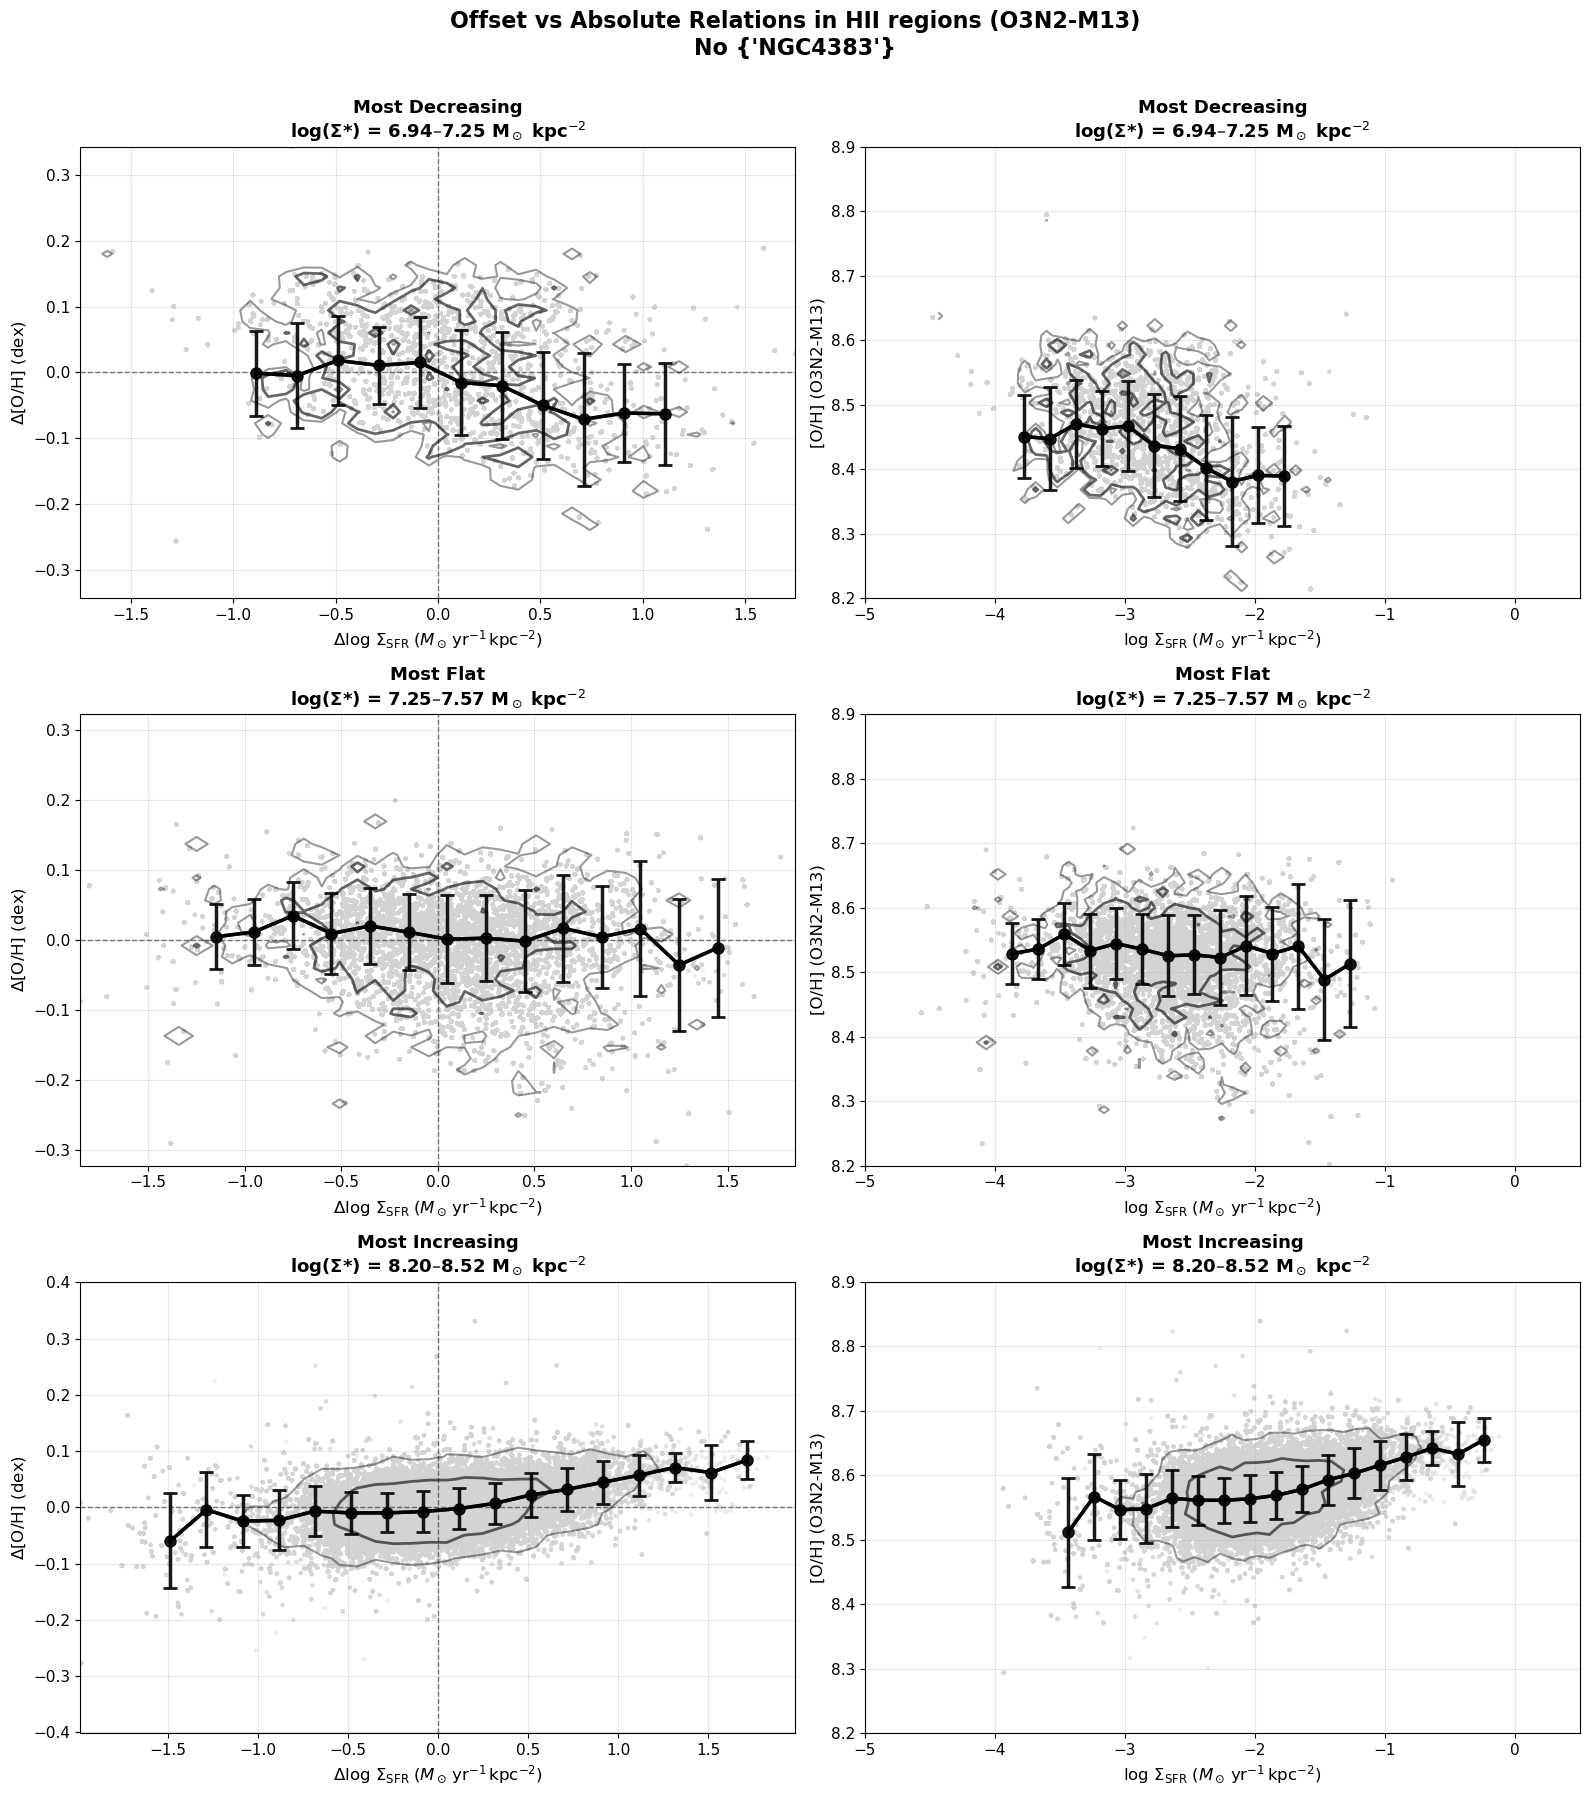


COMPLETED: Combined 3x2 subplot (offset left, absolute right)


In [7]:
# ------------------------------------------------------------------
# Combined: Δ[O/H] vs ΔΣSFR (left) and [O/H] vs ΣSFR (right)
# 3 rows x 2 columns: Most decreasing, most flat, most increasing bins
# Using black for median trends and contours
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

excluded_galaxies = {'NGC4383'}
included_galaxies = []

# Collect data
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("Collecting data for combined 3x2 subplot...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

# Define 12 Σ_* bins
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
n_bins_sigmaM = 12
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

# Analyze all bins and identify 3 specific ones
bin_trends = []

for i in range(n_bins_sigmaM):
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Calculate offsets for this bin
        sfr_mean = np.nanmean(x_bin_HII)
        oh_mean = np.nanmean(y_bin_HII)
        
        delta_sfr = x_bin_HII - sfr_mean
        delta_oh = y_bin_HII - oh_mean
        
        # Calculate binned statistics for absolute values
        sfr_centers_abs, medians_abs, stds_abs, counts_abs, valid_bin_indices_abs = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        # Calculate binned statistics for offsets
        sfr_centers_offset, medians_offset, stds_offset, counts_offset, valid_bin_indices_offset = calculate_binned_stats(
            delta_sfr, delta_oh, bin_width=0.2, min_pixels=20)
        
        if len(medians_abs) >= 10:
            first_median = medians_abs[0]
            last_median = medians_abs[-1]
            trend = last_median - first_median
            
            bin_trends.append({
                'bin_index': i,
                'bin_label': bin_labels_sigmaM[i],
                'trend': trend,
                # Absolute values
                'x_data': x_bin_HII,
                'y_data': y_bin_HII,
                'sfr_centers_abs': sfr_centers_abs,
                'medians_abs': medians_abs,
                'stds_abs': stds_abs,
                'valid_bin_indices_abs': valid_bin_indices_abs,
                # Offset values
                'delta_sfr': delta_sfr,
                'delta_oh': delta_oh,
                'sfr_centers_offset': sfr_centers_offset,
                'medians_offset': medians_offset,
                'stds_offset': stds_offset,
                'valid_bin_indices_offset': valid_bin_indices_offset
            })

# Identify the 3 specific bins
if len(bin_trends) > 0:
    sorted_by_trend = sorted(bin_trends, key=lambda x: x['trend'])
    
    most_decreasing = sorted_by_trend[0]
    most_flat = min(bin_trends, key=lambda x: abs(x['trend']))
    most_increasing = sorted_by_trend[-1]
    
    print(f"\nCreating combined 3x2 subplot:")
    print(f"  Row 1: Most decreasing (Σ_* = {most_decreasing['bin_label']})")
    print(f"  Row 2: Most flat (Σ_* = {most_flat['bin_label']})")
    print(f"  Row 3: Most increasing (Σ_* = {most_increasing['bin_label']})")
    
    # Create 3x2 subplot
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    
    common_ylim = (8.2, 8.9)
    
    selected_bins = [
        (most_decreasing, 'Most Decreasing', 0),
        (most_flat, 'Most Flat', 1),
        (most_increasing, 'Most Increasing', 2)
    ]
    
    # Plot each bin in separate row
    for bin_data, description, row_idx in selected_bins:
        bin_label = bin_data['bin_label']
        
        # ==============================================================
        # LEFT COLUMN: Offset relation (Δ[O/H] vs ΔΣSFR)
        # ==============================================================
        ax_left = axes[row_idx, 0]
        
        delta_sfr = bin_data['delta_sfr']
        delta_oh = bin_data['delta_oh']
        sfr_centers_offset = bin_data['sfr_centers_offset']
        medians_offset = bin_data['medians_offset']
        stds_offset = bin_data['stds_offset']
        valid_bin_indices_offset = bin_data['valid_bin_indices_offset']
        
        # Calculate symmetric axis limits for offset
        max_abs_sfr = np.nanmax(np.abs(delta_sfr))
        max_abs_oh = np.nanmax(np.abs(delta_oh))
        
        # Scatter plot
        ax_left.scatter(delta_sfr, delta_oh, c='lightgray', s=10, alpha=0.4, 
                       edgecolors='none', rasterized=True)
        
        # Create 2D histogram for contours
        H, xedges, yedges = np.histogram2d(delta_sfr, delta_oh, bins=40,
                                           range=[[-max_abs_sfr, max_abs_sfr],
                                                  [-max_abs_oh, max_abs_oh]])
        H = H.T
        
        # Calculate contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted) / np.cumsum(H_sorted)[-1]
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels = [level_95, level_68]
            alphas = [0.4, 0.6]
            linewidths = [1.5, 2.0]
        elif level_95 > level_68:
            levels = [level_68, level_95]
            alphas = [0.6, 0.4]
            linewidths = [2.0, 1.5]
        else:
            levels = [level_68]
            alphas = [0.6]
            linewidths = [2.0]
        
        for level, alpha, lw in zip(levels, alphas, linewidths):
            ax_left.contour(X, Y, H, levels=[level], colors=['black'],
                          linewidths=[lw], alpha=alpha)
        
        # Median trend
        ax_left.errorbar(sfr_centers_offset, medians_offset, yerr=stds_offset, 
                        color='black', marker='o', markersize=8, 
                        linewidth=2.5, capsize=5, capthick=2, alpha=0.9, zorder=10)
        
        for j in range(len(valid_bin_indices_offset) - 1):
            if valid_bin_indices_offset[j + 1] - valid_bin_indices_offset[j] == 1:
                ax_left.plot([sfr_centers_offset[j], sfr_centers_offset[j + 1]], 
                           [medians_offset[j], medians_offset[j + 1]], 
                           color='black', linewidth=2.5, alpha=0.9, zorder=10)
        
        # Center lines
        ax_left.axhline(0, color='k', linestyle='--', linewidth=1.0, alpha=0.5)
        ax_left.axvline(0, color='k', linestyle='--', linewidth=1.0, alpha=0.5)
        
        # Format
        ax_left.set_xlabel(r'$\Delta\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_left.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=12)
        ax_left.set_title(f'{description}\nlog(Σ*) = {bin_label} M$_\\odot$ kpc$^{{-2}}$', fontsize=13, fontweight='bold')
        ax_left.grid(True, alpha=0.3)
        ax_left.set_xlim(-max_abs_sfr, max_abs_sfr)
        ax_left.set_ylim(-max_abs_oh, max_abs_oh)
        ax_left.tick_params(labelsize=11)
        
        # ==============================================================
        # RIGHT COLUMN: Absolute relation ([O/H] vs ΣSFR)
        # ==============================================================
        ax_right = axes[row_idx, 1]
        
        x_data = bin_data['x_data']
        y_data = bin_data['y_data']
        sfr_centers_abs = bin_data['sfr_centers_abs']
        medians_abs = bin_data['medians_abs']
        stds_abs = bin_data['stds_abs']
        valid_bin_indices_abs = bin_data['valid_bin_indices_abs']
        
        # Scatter plot
        ax_right.scatter(x_data, y_data, c='lightgray', s=10, alpha=0.4, 
                        edgecolors='none', rasterized=True)
        
        # Create 2D histogram for contours
        x_min, x_max = np.min(x_data), np.max(x_data)
        y_min, y_max = np.min(y_data), np.max(y_data)
        
        H, xedges, yedges = np.histogram2d(x_data, y_data, bins=40,
                                           range=[[x_min, x_max], [y_min, y_max]])
        H = H.T
        
        # Calculate contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted) / np.cumsum(H_sorted)[-1]
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels = [level_95, level_68]
            alphas = [0.4, 0.6]
            linewidths = [1.5, 2.0]
        elif level_95 > level_68:
            levels = [level_68, level_95]
            alphas = [0.6, 0.4]
            linewidths = [2.0, 1.5]
        else:
            levels = [level_68]
            alphas = [0.6]
            linewidths = [2.0]
        
        for level, alpha, lw in zip(levels, alphas, linewidths):
            ax_right.contour(X, Y, H, levels=[level], colors=['black'],
                           linewidths=[lw], alpha=alpha)
        
        # Median trend
        ax_right.errorbar(sfr_centers_abs, medians_abs, yerr=stds_abs, 
                         color='black', marker='o', markersize=8, 
                         linewidth=2.5, capsize=5, capthick=2, alpha=0.9, zorder=10)
        
        for j in range(len(valid_bin_indices_abs) - 1):
            if valid_bin_indices_abs[j + 1] - valid_bin_indices_abs[j] == 1:
                ax_right.plot([sfr_centers_abs[j], sfr_centers_abs[j + 1]], 
                            [medians_abs[j], medians_abs[j + 1]], 
                            color='black', linewidth=2.5, alpha=0.9, zorder=10)
        
        # Format
        ax_right.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_right.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_right.set_title(f'{description}\nlog(Σ*) = {bin_label} M$_\\odot$ kpc$^{{-2}}$', fontsize=13, fontweight='bold')
        ax_right.grid(True, alpha=0.3)
        ax_right.set_xlim(-5.0, 0.5)
        ax_right.set_ylim(common_ylim)
        ax_right.tick_params(labelsize=11)
    
    # Add overall title
    fig.suptitle(f'Offset vs Absolute Relations in HII regions ({calib_name_HII})\nNo {excluded_galaxies}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # plt.savefig('Combined_Offset_Absolute_3x2_O3N2M13.png', dpi=300, bbox_inches='tight')
    # plt.savefig('Combined_Offset_Absolute_3x2_O3N2M13.pdf', bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("COMPLETED: Combined 3x2 subplot (offset left, absolute right)")
    print("="*80)
else:
    print("\nNo valid bins found for analysis!")


Creating combined plot for 13 galaxies...
Included galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']
Loading IC3392...
  IC3392: 14,884 pixels
Loading NGC4064...
  NGC4064: 7,067 pixels
Loading NGC4192...
  NGC4192: 145,944 pixels
Loading NGC4293...
  NGC4293: 5,715 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4330: 42,998 pixels
Loading NGC4396...
  NGC4396: 81,745 pixels
Loading NGC4419...
  NGC4192: 145,944 pixels
Loading NGC4293...
  NGC4293: 5,715 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4330: 42,998 pixels
Loading NGC4396...
  NGC4396: 81,745 pixels
Loading NGC4419...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4457: 6,310 pixels
Loading NGC4501...
  NGC4501: 261,083 pixels
Loading NGC4522...
  NGC4522: 39,665 pixels
Loading NGC4694...
  NGC4694: 2,585 pixels
Loading NGC4698...
  NGC4419: 7,354 pixels
Loading 

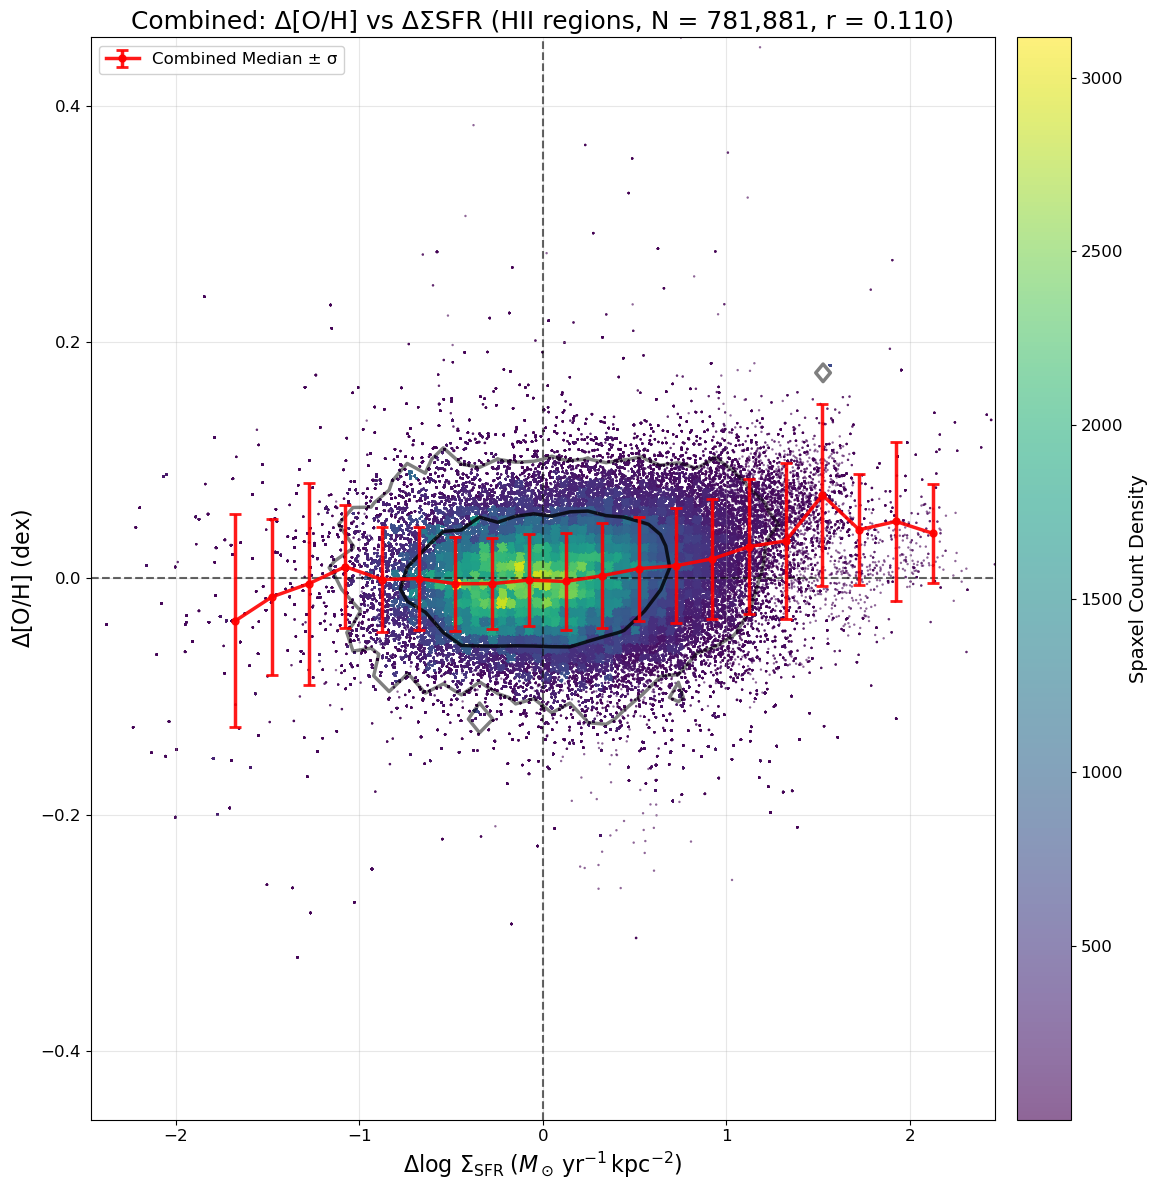


Combined plot complete!


In [8]:
# ------------------------------------------------------------------
# Combined plot: All galaxies in a single panel
# Color-coded by spaxel number counts (density)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.cm as cm
from scipy.stats import gaussian_kde

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Creating combined plot for {len(included_galaxies)} galaxies...")
print(f"Included galaxies: {included_galaxies}")

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Collect data from all galaxies
# ------------------------------------------------------------------
all_delta_sfr = []
all_delta_oh = []
galaxy_data = {}

for gal in included_galaxies:
    try:
        print(f"Loading {gal}...")
        sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_all = valid_sfr & valid_oh

        # Calculate mean values for offset calculation
        sfr_mean = np.nanmean(sigSFR[valid_sfr])
        oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
        
        # Create offset maps (difference from mean)
        sfr_offset = sigSFR - sfr_mean
        oh_offset = oh_o3n2_map - oh_mean

        # Extract valid data points
        delta_sfr = sfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]
        
        # Store for this galaxy
        galaxy_data[gal] = {
            'delta_sfr': delta_sfr,
            'delta_oh': delta_oh
        }
        
        # Add to combined arrays
        all_delta_sfr.extend(delta_sfr)
        all_delta_oh.extend(delta_oh)
        
        print(f"  {gal}: {len(delta_sfr):,} pixels")
        
    except Exception as e:
        print(f"  Error loading {gal}: {e}")

# Convert to numpy arrays
all_delta_sfr = np.array(all_delta_sfr)
all_delta_oh = np.array(all_delta_oh)

print(f"\nTotal combined pixels: {len(all_delta_sfr):,}")

# ------------------------------------------------------------------
# Calculate density for color coding
# ------------------------------------------------------------------
print("Calculating density for color coding...")

# Create 2D histogram to calculate local density
hist_bins = 100  # Higher resolution for better density estimation
H_density, xedges_density, yedges_density = np.histogram2d(
    all_delta_sfr, all_delta_oh, bins=hist_bins
)
H_density = H_density.T

# Function to get density value for each point
def get_density_at_point(x, y, H, xedges, yedges):
    """Get density value at a given point from histogram."""
    x_idx = np.digitize(x, xedges) - 1
    y_idx = np.digitize(y, yedges) - 1
    
    # Clip indices to valid range
    x_idx = np.clip(x_idx, 0, H.shape[1] - 1)
    y_idx = np.clip(y_idx, 0, H.shape[0] - 1)
    
    return H[y_idx, x_idx]

# Get density value for each point
density_values = get_density_at_point(all_delta_sfr, all_delta_oh, 
                                      H_density, xedges_density, yedges_density)

print(f"Density range: {density_values.min():.1f} to {density_values.max():.1f}")

# ------------------------------------------------------------------
# Create combined plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

# Calculate symmetric axis limits for all data
max_abs_sfr = np.nanmax(np.abs(all_delta_sfr))
max_abs_oh = np.nanmax(np.abs(all_delta_oh))

# Plot scatter points color-coded by density
scatter = ax.scatter(all_delta_sfr, all_delta_oh, 
                    c=density_values, s=3, alpha=0.6, 
                    cmap='viridis', edgecolors='none', 
                    rasterized=True)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Spaxel Count Density', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Create 2D histogram for COMBINED contours (in black)
H, xedges, yedges = np.histogram2d(all_delta_sfr, all_delta_oh, bins=50,
                                   range=[[-max_abs_sfr, max_abs_sfr],
                                          [-max_abs_oh, max_abs_oh]])
H = H.T

# Calculate cumulative distribution for contour levels
H_sorted = np.sort(H.flatten())[::-1]
H_cumsum = np.cumsum(H_sorted)
H_cumsum = H_cumsum / H_cumsum[-1]

# Find levels for 68% and 95%
level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]

# Plot COMBINED contours in black
X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
if level_95 < level_68:
    levels_to_plot = [level_95, level_68]
    alphas = [0.5, 0.8]
elif level_95 > level_68:
    levels_to_plot = [level_68, level_95]
    alphas = [0.8, 0.5]
else:
    levels_to_plot = [level_68]
    alphas = [0.8]

if len(levels_to_plot) > 0:
    for level, alpha in zip(levels_to_plot, alphas):
        ax.contour(X, Y, H, levels=[level], colors=['black'],
                  linewidths=[2.5], alpha=alpha)

# Calculate COMBINED median trend (in red for visibility)
bin_centers, medians, stds, counts = calculate_binned_stats(
    all_delta_sfr, all_delta_oh, bin_width=0.2, min_pixels=20)

if len(bin_centers) > 0:
    ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
               color='red', markersize=5, linewidth=2.5, capsize=4, 
               capthick=2, alpha=0.9, label='Combined Median ± σ', zorder=10)

# Calculate Pearson correlation for combined data
n_unique = len(np.unique(np.column_stack([all_delta_sfr, all_delta_oh]), axis=0))
if n_unique >= 20:
    pearson_r, pearson_p = pearsonr(all_delta_sfr, all_delta_oh)
    print(f"\nCombined Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.3e}")
else:
    pearson_r = None
    print(f"\nInsufficient unique data for correlation (N_unique = {n_unique})")

# Set symmetric limits
ax.set_xlim(-max_abs_sfr, max_abs_sfr)
ax.set_ylim(-max_abs_oh, max_abs_oh)

# Add grid and center lines
ax.axhline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
ax.grid(True, alpha=0.3)

# Labels
ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=16)
ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=16)

# Title
if pearson_r is not None:
    title = f'Combined: Δ[O/H] vs ΔΣSFR (HII regions, N = {len(all_delta_sfr):,}, r = {pearson_r:.3f})'
else:
    title = f'Combined: Δ[O/H] vs ΔΣSFR (HII regions, N = {len(all_delta_sfr):,})'
ax.set_title(title, fontsize=18)

# Legend
ax.legend(loc='upper left', fontsize=12, framealpha=0.9)

ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig('Combined_All_Galaxies_Delta_OH_vs_Delta_SigmaSFR_Density.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_All_Galaxies_Delta_OH_vs_Delta_SigmaSFR_Density.pdf', bbox_inches='tight')
plt.show()

print("\nCombined plot complete!")
